In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import math
from tqdm import tqdm
import os

In [2]:
rave_sim_dir = Path('/mnt/d/rave-sim-main/rave-sim-main')
simulations_dir = Path('/mnt/d/rave-sim-main/rave-sim-main/output')
scratch_dir = simulations_dir

In [3]:
sys.path.insert(0, str(rave_sim_dir / "big-wave"))
import multisim
import config
import util

In [4]:
# ===== 薄样品相位验证 (C): 参数定义 =====
#
# 方案说明：
#   1. 加载 wave_before_sample.npy 和 wave_after_sample.npy
#   2. 逐像素相除 T = u_after / u_before (复数除法)
#      → 结果 = 材料因子 × 传播 bulk phase: T = exp(2πi·t/λ) · exp(-2πi·δ·t/λ) · exp(-2π·β·t/λ)
#   3. 样品中心与左右真空区的总相位差消除 bulk phase 影响
#      → Δφ = φ(T_center) - φ(T_vacuum) = -2π·δ·t/λ
#
# 符号说明 (来自 kernels.cu:289-292):
#   exponent.y = -2π·δ·dz/λ  → 材料贡献负相位

C_DENSITY = 1.5  # g/cm^3

thicknesses_um = [10, 20]
thicknesses_m = [t * 1e-6 for t in thicknesses_um]

grid_dir = rave_sim_dir / "grid"
grid_paths = [
    str(grid_dir / f"thin_c_plate_{t}um_25um.npy")
    for t in thicknesses_um
]

def make_config_with_sample(grid_path):
    return {
        "sim_params": {
            "is2d": 'true',
            "N": 16384 * 16384,
            "nx": 16384,
            "ny": 16384,
            "dx": 8.5e-8,
            "z_detector": 4.0,
            "detector_size": 0.85e-3,
            "detector_size_y": 0.85e-3,
            "detector_pixel_size_x": 2e-7,
            "detector_pixel_size_y": 2e-7,
            "chunk_size": 2*1024*1024*1024 // 16,
        },
        "use_disk_vector": False,
        "save_final_u_vectors": False,
        "save_debug_wavefields": True,   # 保存中间波前
        "dtype": "c8",
        "multisource": {
            "type": "points",
            "energy_range": [9999, 10001],
            "x_range": [-1e-6, 1e-6],
            "y_range": [-1e-6, 1e-6],
            "z": 0.0,
            "nr_source_points": 1,
            "seed": 1,
        },
        "elements": [
            {
                "type": "sample",
                "z_start": 1.0,
                "pixel_size_x": 5e-8,
                "pixel_size_y": 5e-8,
                "pixel_size_z": 5e-8,
                "grid_path": grid_path,
                "materials": [["C", C_DENSITY]],
                "x_positions": [0],
                "y_positions": [0],
            },
        ],
    }

ny_sim, nx_sim = 16384, 16384

print("Config template ready (save_debug_wavefields=True)")
print(f"Thicknesses: {thicknesses_um} um")
for p in grid_paths:
    exists = "EXISTS" if Path(p).exists() else "MISSING"
    print(f"  {Path(p).name}: {exists}")

Config template ready (save_debug_wavefields=True)
Thicknesses: [10, 20] um
  thin_c_plate_10um_25um.npy: EXISTS
  thin_c_plate_20um_25um.npy: EXISTS


In [5]:
# ===== 辅助函数：加载波前 + 提取纯材料相位 =====
#
# 方法：
#   T = u_after / u_before  (逐像素复数除法)
#   → T 包含了传播 bulk phase + 材料 phase
#   样品中心与左右真空的相位差 → 抵消 bulk phase → 纯材料相位
#
# 真空区域取同一水平行上对称于中心的区域，
# 球面波前曲率可完全抵消。

ROI_SIZE = 2000
ROI_OFF = (ny_sim - ROI_SIZE) // 2

# ROI = 2000 像素, 每像素 0.085 um, 总宽 = 170 um
# 样品 25 um → ~294 像素, 取 SAMPLE_HW=200
# 真空取距中心 400-800 像素 (34-68 um) 两侧
PIX_UM = 8.5e-8 * 1e6    # 0.085 um
SAMPLE_HW = 200
VAC_INNER = 400
VAC_OUTER = 800


def load_debug_wavefield(sub_dir, name):
    """加载中间波前并返回中心 ROI (complex64, shape (ROI_SIZE, ROI_SIZE))。"""
    path = sub_dir / name
    if not path.exists():
        print(f"  ⚠️ 未找到 {path}")
        return None
    mm = np.load(path, mmap_mode='r').reshape(ny_sim, nx_sim)
    data = mm[ROI_OFF:ROI_OFF+ROI_SIZE, ROI_OFF:ROI_OFF+ROI_SIZE].copy()
    del mm
    return data


def extract_material_phase(u_before, u_after):
    """从 before/after 波前提取纯材料相位偏移。
    
    T = u_after / u_before → 总透射函数
    Δφ = φ(T_center) - φ(T_vacuum) → 材料相位偏移
    
    返回 (phase_diff_rad, T_2d, phase_cross_section)
    """
    cx = u_before.shape[1] // 2  # = 1000

    # 逐像素复数除法
    T = u_after / u_before

    # 样品中心 (水平条带)
    y_slice = slice(cx - SAMPLE_HW // 2, cx + SAMPLE_HW // 2)
    sample_T = T[y_slice, cx - SAMPLE_HW // 2:cx + SAMPLE_HW // 2]

    # 左右真空 (对称于中心)
    left_T  = T[y_slice, cx - VAC_OUTER:cx - VAC_INNER]
    right_T = T[y_slice, cx + VAC_INNER:cx + VAC_OUTER]

    def mean_phase(arr):
        return np.angle(np.mean(arr))

    phi_sample = mean_phase(sample_T)
    phi_left   = mean_phase(left_T)
    phi_right  = mean_phase(right_T)
    phi_vacuum = (phi_left + phi_right) / 2

    phase_diff = phi_sample - phi_vacuum
    print(f"    φ_sample={phi_sample:.4f}, φ_left={phi_left:.4f}, φ_right={phi_right:.4f}, φ_vac={phi_vacuum:.4f}")
    print(f"    >>> Δφ (material) = {phase_diff:.4f} rad")

    # 2D 相位差图：每行以左右真空为参考
    phase_map_2d = np.zeros_like(T, dtype=np.float64)
    for row in range(T.shape[0]):
        ref_l = np.angle(np.mean(T[row, cx - VAC_OUTER:cx - VAC_INNER]))
        ref_r = np.angle(np.mean(T[row, cx + VAC_INNER:cx + VAC_OUTER]))
        ref = (ref_l + ref_r) / 2
        phase_map_2d[row, :] = np.angle(T[row, :]) - ref
        phase_map_2d[row, :] = np.unwrap(phase_map_2d[row, :])

    # 一条一维剖面线 (中心行)
    cross_section = phase_map_2d[cx, :]

    return phase_diff, phase_map_2d, cross_section


def inspect_wavefield(u_complex, title=""):
    amp = np.abs(u_complex)
    phase = np.angle(u_complex)
    print(f"  {title}:")
    print(f"    amplitude: mean={amp.mean():.4e}, min={amp.min():.4e}, max={amp.max():.4e}")
    print(f"    phase:     mean={phase.mean():.4f}, range=[{phase.min():.4f}, {phase.max():.4f}]")

print("Helper functions loaded (T = u_after/u_before, left/right vacuum ref).")

Helper functions loaded (T = u_after/u_before, left/right vacuum ref).


In [6]:
# ===== C 薄板相位仿真 =====
# 加载 wave_before 和 wave_after, 计算 T = u_after / u_before
# 从 T 的 center-vs-vacuum 相位差提取纯材料相位

measured_shifts = []       # Δφ_material (rad)
all_phase_maps = []        # 2D 相位差图
all_cross_sections = []    # 一维剖面线
all_detectors = []         # 探测器强度

for iz, (t_um, t_m, gpath) in enumerate(zip(thicknesses_um, thicknesses_m, grid_paths)):
    print(f"\n{'='*60}")
    print(f"[{iz+1}/{len(thicknesses_um)}] C plate: t = {t_um} um")
    print('='*60)

    config_dict = make_config_with_sample(gpath)
    sim_path = multisim.setup_simulation(config_dict, Path("."), simulations_dir)
    _ = config.load(Path(sim_path / 'computed.yaml'))

    for i in tqdm(range(config_dict["multisource"]["nr_source_points"])):
        os.system(f"CUDA_VISIBLE_DEVICES=0 /mnt/d/rave-sim-main/rave-sim-main/fast-wave/build-Release/fastwave -s {i} {sim_path}")

    sub_dir = sim_path / "00000000"

    # --- 加载波前 ---
    u_before = load_debug_wavefield(sub_dir, "wave_before_sample.npy")
    u_after  = load_debug_wavefield(sub_dir, "wave_after_sample.npy")

    if u_before is not None and u_after is not None:
        inspect_wavefield(u_before, "wave_before_sample")
        inspect_wavefield(u_after,  "wave_after_sample")

        shift, pmap, xsec = extract_material_phase(u_before, u_after)
        measured_shifts.append(shift)
        all_phase_maps.append(pmap)
        all_cross_sections.append(xsec)
    else:
        print(f"  ⚠️ 波前文件缺失")
        for f in sorted(sub_dir.iterdir()):
            if f.is_file():
                print(f"    {f.name}  ({f.stat().st_size/1e6:.0f} MB)")
        measured_shifts.append(0.0)
        all_phase_maps.append(np.zeros((ROI_SIZE, ROI_SIZE)))
        all_cross_sections.append(np.zeros(ROI_SIZE))

    # --- 加载探测器强度（用于可视化）---
    wavefronts = util.load_wavefronts_filtered(sim_path, x_range=(-30e-6, 30e-6))
    wf = np.sum([r[0] for r in wavefronts], axis=0)
    all_detectors.append(wf[0].astype(np.float64))

2026-07-09 22:33:43,292 INFO: Setting up simulation
2026-07-09 22:33:43,294 INFO: 2D mode: nx=16384, ny=16384, dx=8.500e-08, dy=8.500e-08, detector=(8.500e-04 x 8.500e-04) m



[1/2] C plate: t = 10 um


2026-07-09 22:33:44,423 INFO: 2D Nyquist check: dz=1.000e+00, x: Nx=16384, dx=8.500e-08, x_source=-1.000e-06 | y: Ny=16384, dy=8.500e-08, y_source=1.000e-06
2026-07-09 22:33:47,347 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2026/07/20260709_223344456154
  0%|                                                                                             | 0/1 [00:00<?, ?it/s]

[2026-07-09 22:33:48.820] [info] Detector 2D mode
[2026-07-09 22:33:48.820] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/07/20260709_223344456154/00000000
[2026-07-09 22:33:48.820] [info] 2D grid: nx = 16384, ny = 16384, total points = 268435456
[2026-07-09 22:33:48.820] [info] GPU memory required for wavefield: 2048 MB
[2026-07-09 22:33:49.121] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-07-09 22:34:22.764] [info]   Number of optical elements: 1
[2026-07-09 22:36:13.799] [info]   nx=16384, ny=16384, nr_pixels_x=4250, nr_pixels_y=4250
[2026-07-09 22:36:13.799] [info]   detector_pixel_size_x=2e-07, detector_pixel_size_y=2e-07 (effective)
[2026-07-09 22:36:13.799] [info]   current_z=4 (effective), dx=8.5e-08, dy=8.5e-08


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [02:27<00:00, 147.18s/it]

...

2026-07-09 22:36:22,072 INFO: 2D Nyquist check: dz=1.000e+00, x: Nx=16384, dx=8.500e-08, x_source=-1.000e-06 | y: Ny=16384, dy=8.500e-08, y_source=1.000e-06
2026-07-09 22:36:28,118 INFO: Finished setting up simulation in /mnt/d/rave-sim-main/rave-sim-main/output/2026/07/20260709_223622102942
  0%|                                                                                             | 0/1 [00:00<?, ?it/s]

[2026-07-09 22:36:31.137] [info] Detector 2D mode
[2026-07-09 22:36:31.138] [info] Running 2D simulation /mnt/d/rave-sim-main/rave-sim-main/output/2026/07/20260709_223622102942/00000000
[2026-07-09 22:36:31.138] [info] 2D grid: nx = 16384, ny = 16384, total points = 268435456
[2026-07-09 22:36:31.138] [info] GPU memory required for wavefield: 2048 MB
[2026-07-09 22:36:31.445] [info] GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU, Memory: 11.94 GB
[2026-07-09 22:37:05.075] [info]   Number of optical elements: 1
[2026-07-09 22:40:04.421] [info]   nx=16384, ny=16384, nr_pixels_x=4250, nr_pixels_y=4250
[2026-07-09 22:40:04.421] [info]   detector_pixel_size_x=2e-07, detector_pixel_size_y=2e-07 (effective)
[2026-07-09 22:40:04.421] [info]   current_z=4 (effective), dx=8.5e-08, dy=8.5e-08


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [03:37<00:00, 217.13s/it]

[2026-07-09 22:40:05.098] [info] 2D Simulation finished in 214.783527451 seconds


  wave_before_sample:
    amplitude: mean=1.0004e+00, min=6.0192e-01, max=1.9952e+00
    phase:     mean=-0.0046, range=[-3.1416, 3.1416]
  wave_after_sample:
    amplitude: mean=9.9998e-01, min=4.1932e-01, max=1.9950e+00
    phase:     mean=-0.0164, range=[-3.1416, 3.1416]
    φ_sample=-1.8742, φ_left=1.2827, φ_right=1.2828, φ_vac=1.2827
    >>> Δφ (material) = -3.1570 rad


In [7]:
# ===== 相位偏移定量验证 =====
#
# T = u_after / u_before  (复数除法)
# T_center / T_vacuum  → 传播 bulk phase 抵消 → 纯材料相位偏移
#
# 理论: Δφ = -2π·δ·t/λ
# 负号来自 CUDA kernel: exponent.y = -2π·δ·dz/λ (kernels.cu:291)

from nist_lookup.xraydb_plugin import xray_delta_beta

energy = 10000  # eV
delta_C, beta_C, atlen_C = xray_delta_beta("C", 1.5, energy)
lam = 6.62607004e-34 * 299792458.0 / (energy * 1.602176634e-19)

# 理论材料相位偏移 (负值)
slope_theory = -2 * math.pi * delta_C / lam  # rad/m
phase_theory = np.array([slope_theory * t for t in thicknesses_m])

print("=" * 70)
print("Phase Shift Validation: C thin plates")
print("=" * 70)
print(f"Energy: {energy} eV,  Wavelength: {lam:.4e} m")
print(f"delta_C = {delta_C:.6e}")
print(f"beta_C  = {beta_C:.6e}")
print(f"理论斜率 = {slope_theory:.4e} rad/m  (= -2π·δ/λ)")
print()

print(f"{'t (um)':<10} {'Δφ_sim (rad)':<18} {'Δφ_theory (rad)':<20} {'偏差(rad)':<12} {'ratio':<10}")
print("-" * 70)
for t, meas, theo in zip(thicknesses_um, measured_shifts, phase_theory):
    err = meas - theo
    ratio = meas / theo if theo != 0 else 0
    print(f"{t:<10} {meas:<18.4f} {theo:<20.4f} {err:<+12.4f} {ratio:<10.4f}")

# 线性拟合
if len(thicknesses_m) >= 2:
    coeffs = np.polyfit(thicknesses_m, measured_shifts, 1)
    slope_sim = coeffs[0]
    intercept = coeffs[1]
    slope_err = abs(slope_sim - slope_theory) / abs(slope_theory) * 100

    print("-" * 70)
    print(f"Linear fit: Δφ = {slope_sim:.4e} · t + {intercept:.4f}")
    print(f"Theory:      Δφ = {slope_theory:.4e} · t")
    print(f"Slope deviation: {slope_err:.2f}%")

    if slope_err < 10:
        print("\n✅ 相位验证通过: 偏差 < 10%")
    else:
        print(f"\n⚠️ 偏差 {slope_err:.2f}% (> 10%)")
else:
    print("\n⚠️ 厚度点不足 2 个，跳过线性拟合")

Phase Shift Validation: C thin plates
Energy: 10000 eV,  Wavelength: 1.2398e-10 m
delta_C = 3.116195e-06
beta_C  = 3.361928e-09
理论斜率 = -1.5792e+05 rad/m  (= -2π·δ/λ)

t (um)     Δφ_sim (rad)       Δφ_theory (rad)      偏差(rad)      ratio     
----------------------------------------------------------------------
10         -1.5784            -1.5792              +0.0008      0.9995    
20         -3.1570            -3.1584              +0.0014      0.9995    
----------------------------------------------------------------------
Linear fit: Δφ = -1.5786e+05 · t + 0.0002
Theory:      Δφ = -1.5792e+05 · t
Slope deviation: 0.04%

✅ 相位验证通过: 偏差 < 10%


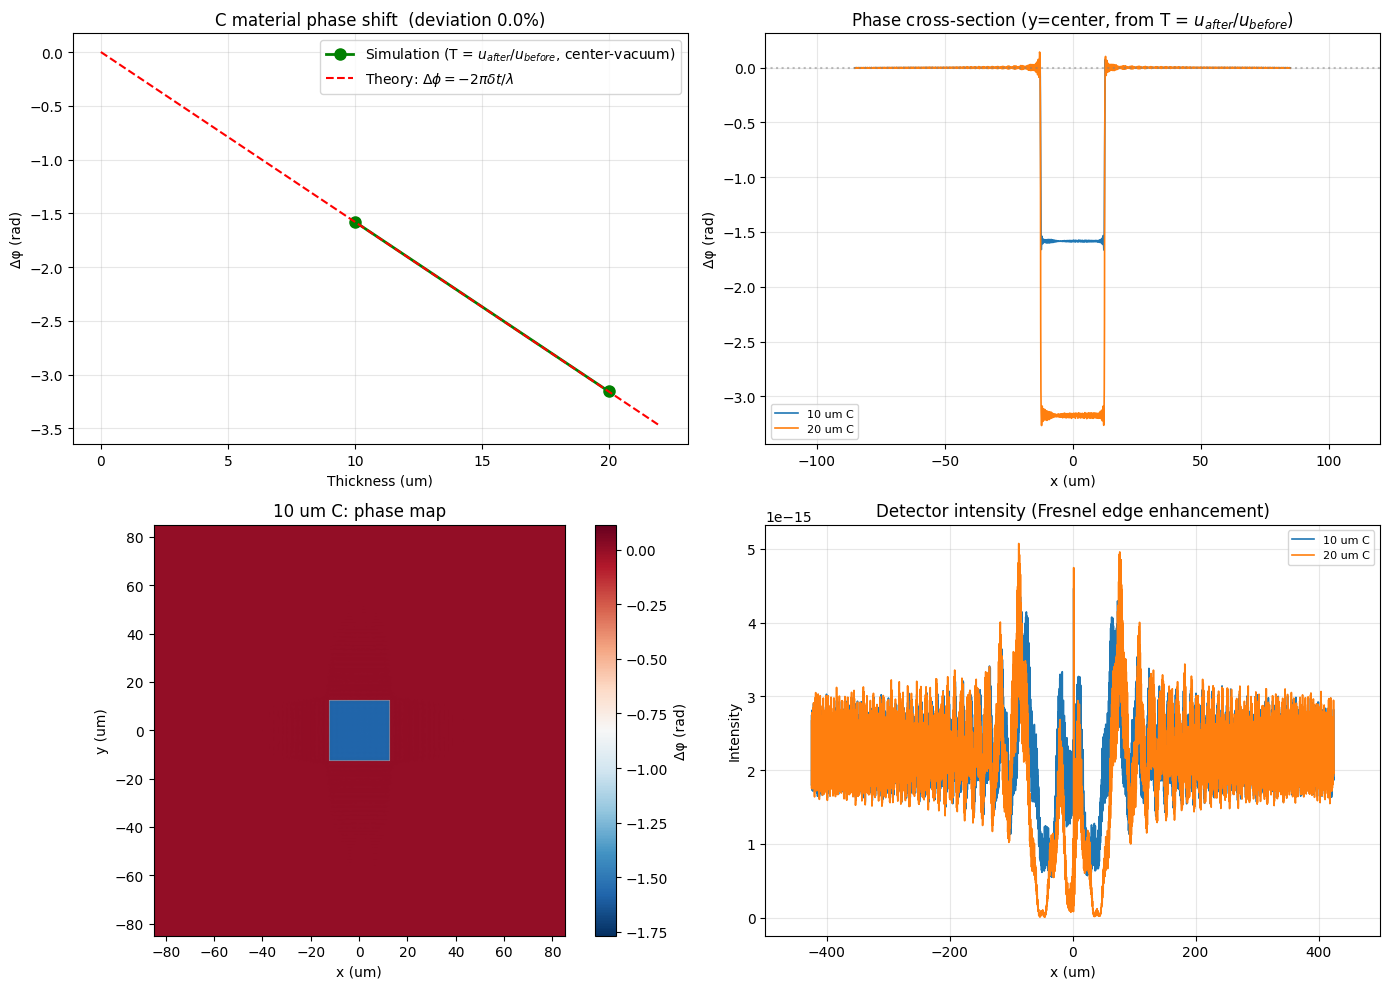

Saved thin_c_phase_validation.png


In [8]:
# ===== 可视化 =====

det_pixel_um = 0.2           # 200 nm -> um
sim_pix_um = 8.5e-8 * 1e6    # 0.085 um

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) 材料相位 vs 厚度
ax = axes[0, 0]
z_fit = np.linspace(0, max(thicknesses_um) * 1.1, 100)
ax.plot(thicknesses_um, measured_shifts, 'go-', lw=2, markersize=8,
        label='Simulation (T = $u_{after}/u_{before}$, center-vacuum)')
ax.plot(z_fit, slope_theory * z_fit * 1e-6, 'r--', lw=1.5,
        label=r'Theory: $\Delta\phi = -2\pi\delta t/\lambda$')
ax.set_xlabel('Thickness (um)')
ax.set_ylabel('Δφ (rad)')
ax.set_title(f'C material phase shift  (deviation {slope_err:.1f}%)')
ax.legend()
ax.grid(alpha=0.3)

# (b) 一维剖面线 (中心行)
ax = axes[0, 1]
for iz, (t, xsec) in enumerate(zip(thicknesses_um, all_cross_sections)):
    x_um = (np.arange(len(xsec)) - len(xsec) // 2) * sim_pix_um
    ax.plot(x_um, xsec, lw=1.2, label=f'{t} um C')
ax.axhline(0, color='gray', ls=':', alpha=0.5)
ax.set_xlabel('x (um)')
ax.set_ylabel('Δφ (rad)')
ax.set_title('Phase cross-section (y=center, from T = $u_{after}/u_{before}$)')
ax.legend(fontsize=8)
ax.set_xlim(-120, 120)
ax.grid(alpha=0.3)

# (c) 2D 相位图 (10 um C)
ax = axes[1, 0]
if len(all_phase_maps) > 0:
    pmap = all_phase_maps[0]
    half = pmap.shape[0] // 2
    extent = [-half * sim_pix_um, half * sim_pix_um] * 2
    im = ax.imshow(pmap, cmap='RdBu_r', extent=extent, origin='lower')
    plt.colorbar(im, ax=ax, label='Δφ (rad)')
    ax.set_title(f'{thicknesses_um[0]} um C: phase map')
    ax.set_xlabel('x (um)')
    ax.set_ylabel('y (um)')

# (d) 探测器强度 (Fresnel 边缘增强)
ax = axes[1, 1]
for iz, (t, det) in enumerate(zip(thicknesses_um, all_detectors)):
    ny_d, nx_d = det.shape
    line = det[ny_d // 2, :]
    x_um = (np.arange(len(line)) - nx_d // 2) * det_pixel_um
    ax.plot(x_um, line, lw=1.2, label=f'{t} um C')
ax.set_xlabel('x (um)')
ax.set_ylabel('Intensity')
ax.set_title('Detector intensity (Fresnel edge enhancement)')
ax.legend(fontsize=8)
ax.set_xlim(-500, 500)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('thin_c_phase_validation.png', dpi=150)
plt.show()
print('Saved thin_c_phase_validation.png')

Absolute phase analysis: spherical wavefront curvature

Geometry:
  Source z    = 0 m (point source)
  Sample z    = 1.0 m
  λ           = 1.2398e-10 m (10 keV)

Parabolic phase fit (center row, wave_before_sample):
  φ(x) = (2.5338e+10)·x² + (-8.2316e+04)·x + (-190.2475)
  Quadratic coefficient (fit):    a_fit = 2.5338e+10  rad/m²
  Quadratic coefficient (theory): a_th  = -2.5339e+10  rad/m²
  Ratio: -0.999978
  Effective z from fit:  z_eff = -1.0000 m
  Expected z:            z      = 1.0000 m

Absolute phase budget

Spherical wavefront across ROI (2000 px = 170 um):
  Δφ_curvature (center ↔ edge) = 183.07 rad
    → 包裹在 [-π, π] 后不可分辨

Material phase shift (10 um C):
  Δφ_material = -1.5784 rad
  Ratio |Δφ_material / Δφ_curvature| = 0.8622%

Material phase shift (20 um C):
  Δφ_material = -3.1570 rad
  Ratio |Δφ_material / Δφ_curvature| = 1.7244%


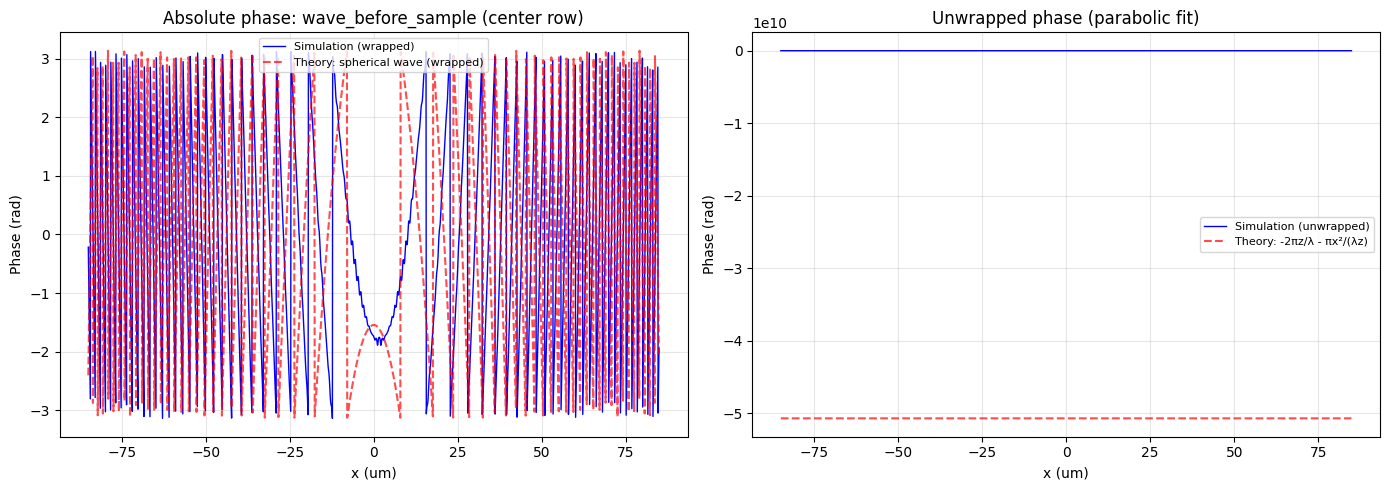


Saved thin_c_absolute_phase_analysis.png


In [9]:
# ===== 绝对相位分析：球面波前曲率定量计算 =====
#
# 点源在 z=0，样品在 z=1.0 m，
# wave_before_sample.npy 记录的是点源球面波在样品平面的相位分布。
# 球面波相位（傍轴近似）:
#   φ(x, y) ≈ -2π·z/λ - π·[(x-xs)² + (y-ys)²] / (λ·z) + φ₀
#
# 这列计算：
#   1) 从 wave_before_sample 取出中心行相位，解缠绕后拟合抛物线曲率
#   2) 与理论曲率 -π/(λ·z) 对比，验证源距离
#   3) 展示绝对相位预算：球面曲率 ~上百 rad vs 材料相位 ~1.58 rad

if len(all_detectors) > 0 and all_phase_maps[0] is not None:
    print("=" * 70)
    print("Absolute phase analysis: spherical wavefront curvature")
    print("=" * 70)
    
    # 几何参数
    z_sample = 1.0e0        # m (样品 z 位置)
    energy = 10000           # eV
    lam = 6.62607004e-34 * 299792458.0 / (energy * 1.602176634e-19)
    dx_sim = 8.5e-8          # m (仿真网格间距)
    
    # 取最后一组仿真的 wave_before_sample 做分析
    sub_dir_last = sim_path / "00000000"  # 最后运行的仿真
    u_before_last = load_debug_wavefield(sub_dir_last, "wave_before_sample.npy")
    
    if u_before_last is not None:
        # --- 1. 提取中心行相位并解缠绕 ---
        cx = u_before_last.shape[1] // 2
        raw_phase = np.angle(u_before_last[cx, :])
        unwrapped = np.unwrap(raw_phase)          # 1D 解缠绕
        x_pix = np.arange(u_before_last.shape[1]) - cx
        x_m = x_pix * dx_sim                       # 坐标 (m)
        
        # 理论球面波相位（傍轴）：φ(x) = -2π·z/λ - π·x²/(λ·z) + φ₀
        phi_center = -2 * math.pi * z_sample / lam
        phi_parabola_theory = -math.pi / (lam * z_sample) * x_m**2
        phi_total_theory = phi_center + phi_parabola_theory
        
        # 包裹到 [-π, π]
        phi_total_wrapped = (phi_total_theory + math.pi) % (2 * math.pi) - math.pi
        
        # 拟合测量数据：φ_meas = a·x² + b（去掉整体相位偏移）
        coeffs = np.polyfit(x_m, unwrapped, 2)
        a_fit = coeffs[0]    # 二次项系数
        b_fit = coeffs[1]    # 一次项
        c_fit = coeffs[2]    # 常数项
        
        # 理论二次项系数
        a_theory = -math.pi / (lam * z_sample)
        
        # 从拟合曲率反推有效距离
        z_effective = -math.pi / (lam * a_fit)
        
        print(f"\nGeometry:")
        print(f"  Source z    = 0 m (point source)")
        print(f"  Sample z    = {z_sample} m")
        print(f"  λ           = {lam:.4e} m ({energy/1000:.0f} keV)")
        
        print(f"\nParabolic phase fit (center row, wave_before_sample):")
        print(f"  φ(x) = ({a_fit:.4e})·x² + ({b_fit:.4e})·x + ({c_fit:.4f})")
        print(f"  Quadratic coefficient (fit):    a_fit = {a_fit:.4e}  rad/m²")
        print(f"  Quadratic coefficient (theory): a_th  = {a_theory:.4e}  rad/m²")
        print(f"  Ratio: {a_fit/a_theory:.6f}")
        print(f"  Effective z from fit:  z_eff = {z_effective:.4f} m")
        print(f"  Expected z:            z      = {z_sample:.4f} m")
        
        # --- 2. 绝对相位变化量计算 ---
        print(f"\n{'='*70}")
        print(f"Absolute phase budget")
        print(f"{'='*70}")
        
        # ROI 内最大相位变化（球面波曲率引起）
        x_max = dx_sim * u_before_last.shape[1] / 2     # ROI 边缘
        dphi_spherical = abs(a_theory * x_max**2)        # 中心 vs ROI 边缘
        print(f"\nSpherical wavefront across ROI ({u_before_last.shape[1]} px = {x_max*2*1e6:.0f} um):")
        print(f"  Δφ_curvature (center ↔ edge) = {dphi_spherical:.2f} rad")
        print(f"    → 包裹在 [-π, π] 后不可分辨")
        
        # 材料相位
        for t_um, shift in zip(thicknesses_um, measured_shifts):
            print(f"\nMaterial phase shift ({t_um} um C):")
            print(f"  Δφ_material = {shift:.4f} rad")
            print(f"  Ratio |Δφ_material / Δφ_curvature| = {abs(shift/dphi_spherical)*100:.4f}%")
        
        # --- 3. 可视化对比 ---
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        
        # 左图：原始包裹相位 vs 理论包裹
        ax = axes[0]
        phi_wrapped_meas = np.angle(u_before_last[cx, :])
        ax.plot(x_m*1e6, phi_wrapped_meas, 'b-', lw=1, label='Simulation (wrapped)')
        ax.plot(x_m*1e6, phi_total_wrapped, 'r--', lw=1.5, alpha=0.7,
                label=f'Theory: spherical wave (wrapped)')
        ax.set_xlabel('x (um)')
        ax.set_ylabel('Phase (rad)')
        ax.set_title('Absolute phase: wave_before_sample (center row)')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        
        # 右图：解缠绕相位 vs 理论抛物线
        ax = axes[1]
        ax.plot(x_m*1e6, unwrapped, 'b-', lw=1, label='Simulation (unwrapped)')
        ax.plot(x_m*1e6, phi_total_theory, 'r--', lw=1.5, alpha=0.7,
                label=f'Theory: -2πz/λ - πx²/(λz)')
        ax.set_xlabel('x (um)')
        ax.set_ylabel('Phase (rad)')
        ax.set_title('Unwrapped phase (parabolic fit)')
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
        
        plt.tight_layout()
        plt.savefig('thin_c_absolute_phase_analysis.png', dpi=150)
        plt.show()
        print('\nSaved thin_c_absolute_phase_analysis.png')
    else:
        print("⚠️ 无法加载 wave_before_sample.npy，跳过绝对相位分析")
else:
    print("⚠️ 无仿真数据，需要先运行仿真")